<a href="https://colab.research.google.com/github/Potdooshami/1T-TaS2-point-defect-analysis/blob/master/Lawler_Fujita(easy_background_first).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataprocessing environment setting

In [ ]:
!pip install gwyfile
from google.colab import drive
drive.mount('/content/drive')

load `.gwy` files' list

In [ ]:
dir = '/content/drive/MyDrive/2HDWN/phaseAnalysis'
import os
files = os.listdir(dir)
files_no_ext = [f.replace('.gwy', '') for f in files]

load `.gwy` files' header

In [ ]:
import pandas as pd
fnTbl = '/content/drive/MyDrive/2HDWN/dataTbl.xlsx'
df = pd.read_excel(fnTbl)
df['fileName_no_ext'] = df['fileName_corrected_ntn'].str.replace('.sxm', '', regex=False)
df = df.set_index('fileName_no_ext')
dfCrrent =df.loc[files_no_ext]
dfCrrent = dfCrrent.iloc[[0,1,2,3,4,6,7,8]] #remove redundancy
dfCrrent

# Choose a file

In [ ]:
dfCrrent[['scan_range_1_sxm','bias_sxm', 'scan_pixels_1_sxm']]

In [ ]:
fn = '2HTaSe2_bae_110K012'# @param ['2HTaSe2_ah035','2HTaSe2_ao_115K037','2HTaSe2_aj036','2HTaSe2_ap_118K002','2HTaSe2_bae_110K012','2HTaSe2_bae_110K013','2HTaSe2_bad_78K097','2HTaSe2_bad_78K100']
fnlong = dir +'/'+ fn +'.gwy'

In [ ]:
sz_nano = dfCrrent.loc[fn][['scan_range_1_sxm','scan_range_2_sxm']].values *1000000000
pxl = dfCrrent.loc[fn][['scan_pixels_1_sxm','scan_pixels_2_sxm']].values

## Declare 1st array

In [ ]:
import gwyfile
import numpy as np

# gwy open
container = gwyfile.load(fnlong)
arr = container['/0/data']['data']
arr = arr.reshape(pxl)

In [ ]:
import matplotlib.pyplot as plt
p = (10**(-12))
plt.figure(figsize=(20, 20)) # Adjust the size as needed
img = plt.imshow(arr,cmap='afmhot',vmin=-13*p,vmax=18*p)

In [ ]:
plt.imshow(arr,cmap='afmhot')
from scipy.ndimage import gaussian_filter

# Remove background

### High-pass filtering

In [ ]:
def ceilcut(image,threshold):
  imagec = image.copy()
  imagec[image>threshold] = threshold
  return imagec
from scipy.ndimage import gaussian_filter

In [ ]:
param_ceilCut = 10 # @param
param_sigma = 5 # @param
from scipy.ndimage import gaussian_filter
arr_c = ceilcut(arr,p*param_ceilCut)
arr_c_g = gaussian_filter(arr_c,sigma=param_sigma)
arr_c_g_m = arr - arr_c_g

####Visualization

In [ ]:
def plot_result(image, background):
    fig, ax = plt.subplots(nrows=1, ncols=3)

    ax[0].imshow(image, cmap='gray')
    ax[0].set_title('Original image')
    ax[0].axis('off')

    ax[1].imshow(background, cmap='gray')
    ax[1].set_title('Background')
    ax[1].axis('off')

    ax[2].imshow(image - background, cmap='gray')
    ax[2].set_title('Result')
    ax[2].axis('off')

    fig.tight_layout()
    return fig,ax


##### Original

In [ ]:
plt.figure(figsize=(20, 20)) # Adjust the size as needed
plt.imshow(arr,cmap='afmhot',vmin=-13*p,vmax=18*p)

#####Compares

In [ ]:
plot_result(arr, arr_c_g)

##### Filtered

In [ ]:
plt.figure(figsize=(20, 20)) # Adjust the size as needed

plt.imshow(arr_c_g_m,cmap='afmhot',vmin=-13*p,vmax=18*p)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

### Cluster Removing

In [ ]:
import numpy as np

def replace_with_average(img_original, bw):
  """
  Replaces the value of specific part of image as average.

  Args:
    img_original: (n,m) float array, the original image.
    bw: (n,m) boolean array, the mask where True indicates the part to be replaced.

  Returns:
    img_cleaned: (n,m) float array, the image with the specified part replaced by the average.
  """
  # Calculate the average of the values in img_original where bw is False
  average_false_part = np.mean(img_original[~bw])

  # Create a copy of the original image
  img_cleaned = img_original.copy()

  # Replace the values in img_cleaned where bw is True with the calculated average
  img_cleaned[bw] = average_false_part

  return img_cleaned

In [ ]:
cutted =  arr_c_g_m>p*5


In [ ]:
from skimage.morphology import binary_opening, disk

# Define the size of the structuring element (adjust as needed)
selem_size = 6 # Example size, you might need to tune this
selem = disk(selem_size)

# Apply the binary opening operation
opened = binary_opening(cutted, footprint=selem)

In [ ]:
opened_rm = opened.copy()
opened_rm[0:100,:] = False

In [ ]:
arr_c_g_mm = replace_with_average(arr_c_g_m , opened_rm)

In [ ]:
# plt.figure(figsize=(20, 20)) # Adjust the size as needed
# plt.imshow(cutted,cmap='gray')
# ax = plt.gca()
# ax.set_xticks([])
# ax.set_yticks([])

In [ ]:
# plt.figure(figsize=(20, 20)) # Adjust the size as needed
# plt.imshow(opened,cmap='gray')
# ax = plt.gca()
# ax.set_xticks([])
# ax.set_yticks([])

In [ ]:
# plt.figure(figsize=(20, 20)) # Adjust the size as needed
# plt.imshow(opened_rm,cmap='gray')
# ax = plt.gca()
# ax.set_xticks([])
# ax.set_yticks([])


In [ ]:
plt.figure(figsize=(20, 20)) # Adjust the size as needed

plt.imshow(arr_c_g_mm,cmap='afmhot')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

In [ ]:
# Define a threshold for identifying salt-like noise (adjust as needed)
# This threshold might need tuning based on the characteristics of your noise
noise_threshold = 150 * p # Example threshold, adjust as necessary based on your data

# Create a boolean mask where True indicates potential noise (values above the threshold)
noise_mask = arr_c_g_mm > noise_threshold

# Use the replace_with_average function to replace the masked noise with the average of the rest of the image
arr_cleaned_noise = replace_with_average(arr_c_g_mm, noise_mask)

# Display the cleaned image
plt.figure(figsize=(20, 20))
plt.imshow(arr_cleaned_noise, cmap='afmhot') # You might want a different colormap
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])
plt.title('Image after removing salt-like noise')
plt.show()

### Remove tip tick

In [ ]:
plt.figure(figsize=(20, 20)) # Adjust the size as needed

plt.imshow(arr_c_g_mm>100*p,cmap='afmhot')
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

In [ ]:
def imshowL(arr):
  plt.figure(figsize=(20, 20)) # Adjust the size as needed
  plt.imshow(arr,cmap='afmhot')
  ax = plt.gca()
  ax.set_xticks([])
  ax.set_yticks([])

In [ ]:
# Perform a circular shift of arr_c_g_mm along axis=0 by 1 pixel
arr_shifted = np.roll(arr_c_g_mm, shift=300, axis=0)

# Display the shifted array (optional)
imshowL(arr_shifted)

In [ ]:
arr_shifted = np.roll(arr_c_g_mm, shift=1, axis=0)
arr2 = arr_c_g_mm - arr_shifted
arr3 = arr2>30*p
arr_c_g_mmm = replace_with_average(arr_c_g_mm, arr3)
plt.figure(figsize=(20, 20)) # Adjust the size as needed
plt.imshow(arr_c_g_mmm,cmap='afmhot',vmin=-13*p,vmax=18*p)
ax = plt.gca()
ax.set_xticks([])
ax.set_yticks([])

In [ ]:
arr_c_g_mmmm = arr_c_g_mmm - np.mean(arr_c_g_mmm)

In [ ]:
# from skimage.measure import label, regionprops

# # Label connected components in the opened image
# labeled_image = label(opened)

# # Get properties of each labeled region
# regions = regionprops(labeled_image)

# print(f"Number of segmented objects: {len(regions)}")

phasemap

# FFT peak find

In [ ]:
from scipy.fft import fft2, fftshift
from skimage.feature import peak_local_max
def fft2show(arr_cln,vmin,vmax):
  fft_result = fft2(arr_cln)
  fft_result_shifted = fftshift(fft_result)
  magnitude_spectrum = np.abs(fft_result_shifted)
  plt.figure(figsize=(10, 10))
  plt.imshow(magnitude_spectrum, cmap='gray', vmin=vmin, vmax=vmax)
  plt.title('Magnitude Spectrum of 2D FFT')
  return  magnitude_spectrum
def fft2pkfnd(fft2abs,threshold,choose):
  coordinates = peak_local_max(fft2abs, min_distance=100, threshold_abs = threshold)
  plt.scatter(coordinates[:, 1], coordinates[:, 0], s=50, facecolors='none', edgecolors='r')
  for ipeak in range(coordinates.shape[0]):
    plt.text(coordinates[ipeak,1],coordinates[ipeak,0],str(ipeak), color='g')
  coordinates_choose = coordinates[choose,:]
  print(coordinates_choose)
  print(coordinates_choose.shape[0])
  for ipeak in range(coordinates_choose.shape[0]):
    plt.text(coordinates_choose[ipeak,1],coordinates_choose[ipeak,0],str(ipeak), color='b',size= 20)
    pk_all = coordinates - (np.array(fft2abs.shape)/2)
    pk_choose = pk_all[choose,:]
  return pk_choose,pk_all
arr_cln = arr_c_g_mmm

##handles

In [ ]:
vmin = 0 # @param
vmax = 0.0000001 # @param
threshold = 0.00000002 # @param
choose = [1,3,6] # @param

## Visualization for Check

In [ ]:
fft2abs = fft2show(arr_cln,vmin,vmax)
pk_choose,pk_all = fft2pkfnd(fft2abs,threshold,[0,5,6])
print(pk_choose)
print(pk_all)

#Remove extrinsic drift effect

In [ ]:
def generate_sine_wave_from_k(k_value,  arr_shape,phi=0):
  """
  Generates a 2D sine wave based on a k-value (spatial frequency vector).

  Args:
    k_value: A 2-element numpy array representing the centered k-vector
             (ky_c, kx_c) in pixel units from the FFT.
    arr_shape: A tuple (image_height, image_width) representing the shape
               of the desired output image in pixels.
    phi: Optional phase offset in radians. Defaults to 0.

  Returns:
    A 2D numpy array representing the sine wave.
  """
  # Get the centered k-vector components
  ky_c = k_value[0]
  kx_c = k_value[1]
  image_height, image_width = arr_shape
  # Create a grid of spatial coordinates (pixel indices)
  y_indices, x_indices = np.indices((image_height, image_width))

  # Calculate spatial frequencies in cycles per pixel
  spatial_freq_x_cpp = kx_c / image_width
  spatial_freq_y_cpp = ky_c / image_height

  # Construct the full argument for the sine wave, including the 2*pi factor and phase
  argument = 2 * np.pi * (spatial_freq_x_cpp * x_indices + spatial_freq_y_cpp * y_indices) + phi

  # Generate the sine wave
  sine_wave = np.sin(argument)

  return sine_wave
def kdispacementmap(arr,k,sig):
  sw = generate_sine_wave_from_k(k,  arr.shape,0)
  cw = generate_sine_wave_from_k(k,  arr.shape,np.pi/2)
  sprod = gaussian_filter(sw*arr,sig)
  cprod = gaussian_filter(cw*arr,sig)
  xprod = cprod +sprod*1j
  return xprod
def visxprod(xprod):
  fig,axs = plt.subplots(2,2,figsize=(10, 10))

  #sw = generate_sine_wave_from_k(k,  aff_br.shape,0)
  tns = ['Re','Img','theta','radial']
  isbs = [0,0,1,1]
  jsbs = [0,1,0,1]
  funcs = [np.real, np.imag, np.angle, np.abs]
  cmaps = ['PuOr','vanimo','twilight','plasma']
  for isb,jsb,func,tn,cmap in zip(isbs,jsbs,funcs,tns,cmaps):
    reimg = func(xprod)
    #if tn == 'theta':
     # reimg = unwrap_phase(reimg)
    #else:
    vmin,vmax = auto_clim(reimg, method='percentile')
    im = axs[isb,jsb].imshow(reimg, cmap=cmap,vmin=vmin,vmax=vmax)
    plt.colorbar(im, ax=axs[isb,jsb])
    axs[isb,jsb].set_title(tn)
    axs[isb,jsb].set_xticks([])
    axs[isb,jsb].set_yticks([])
  return fig, axs

def auto_clim(data, method='percentile', lower=1, upper=99):
  """
  data: 2D array
  method: 'percentile' or 'std'
  """
  if method == 'percentile':
      vmin, vmax = np.percentile(data, [lower, upper])
  elif method == 'std':
      mean = np.mean(data)
      std = np.std(data)
      vmin, vmax = mean - std, mean + std
  else:
      raise ValueError("method must be 'percentile' or 'std'")
  return vmin, vmax

In [ ]:
ik = 1 # @param
k = pk_choose[ik]/3
sig = 10 # @param
xprod = kdispacementmap(arr_cln,k,sig)
visxprod(xprod)
plt.suptitle("k"+str(ik))

In [ ]:
ks_Latt = pk_choose
ks_CDW = pk_choose/3

In [ ]:
def wrap_phase(unwrapped_phase):
  """
  Wraps unwrapped phase data into the range of (-pi, pi].

  Args:
    unwrapped_phase: A numpy array containing the unwrapped phase data.

  Returns:
    A numpy array containing the wrapped phase data.
  """
  wrapped_phase = np.mod(unwrapped_phase + np.pi, 2 * np.pi) - np.pi
  return wrapped_phase
from skimage.restoration import unwrap_phase

In [ ]:

sig = 6 # @param
angle_restores = []

for ik in range(3):
  k_Latt = ks_Latt[ik]
  k_CDW = ks_CDW[ik]
  angle_restore = (unwrap_phase(np.angle(kdispacementmap(arr_cln,k_CDW,sig)))
   - unwrap_phase(np.angle(kdispacementmap(arr_cln,k_Latt,sig)))/3)
  angle_restores.append(angle_restore)




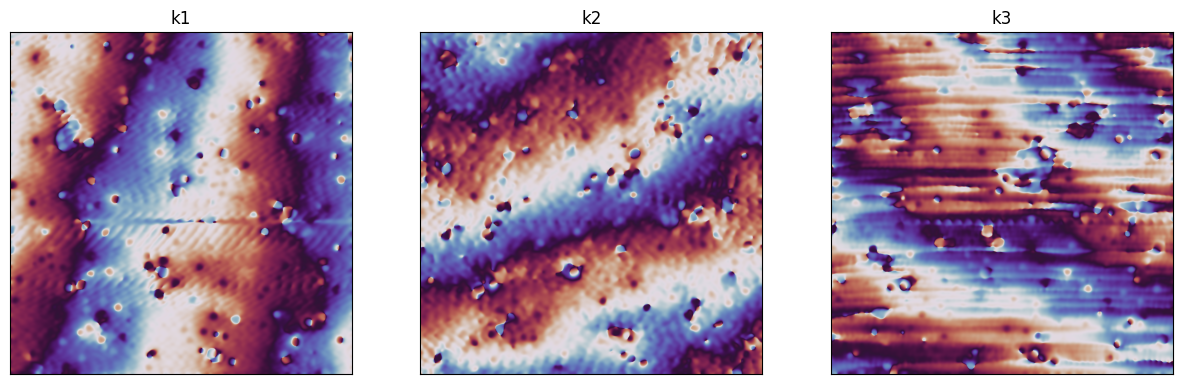

In [41]:
fig,axs = plt.subplots(1,3,figsize=(15, 15))
tns = ['k1','k2','k3']
yns = ['CDW','atom','CDW_compensate']
for ik,tn in zip(range(3),tns):
    reimg = angle_restores[ik]
    reimg = wrap_phase(reimg)
    axs[ik].imshow(reimg, cmap='twilight')
    axs[ik].set_title(tn)
    axs[ik].set_xticks([])
    axs[ik].set_yticks([])